# WiDS Datathon 2020 - Meeting 3: Model Explainability

This notebook covers the explainability of the best model from Meeting 2 (**CatBoost**, test ROC-AUC = 0.907) for ICU mortality prediction (`hospital_death`).  
We address three questions asked by the ICU director:

1. **Global explainability** : Which features drive the model overall?
2. **Local explainability** : Why did the model assign a specific risk to *this* patient?
3. **APACHE comparison** : How do our model's most important variables compare to those used by the established APACHE IVa score?

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from lime.lime_tabular import LimeTabularExplainer

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SAVE_DIR = Path('best_model_info')

In [2]:
# WiDSFeatureBuilder must be defined before loading the joblib artifact
# (joblib uses pickle, which requires the class to be importable at load time)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder

MISSING_RATE_CUTOFF   = 0.80
MISSING_FLAG_MIN_RATE = 0.05
APACHE_PROB_COLS      = ["apache_4a_hospital_death_prob", "apache_4a_icu_death_prob"]

class WiDSFeatureBuilder(BaseEstimator, TransformerMixin):
    def __init__(self, missing_rate_cutoff=MISSING_RATE_CUTOFF,
                 missing_flag_min_rate=MISSING_FLAG_MIN_RATE, drop_cols=None):
        self.missing_rate_cutoff   = missing_rate_cutoff
        self.missing_flag_min_rate = missing_flag_min_rate
        self.drop_cols             = drop_cols or list(APACHE_PROB_COLS)

    def fit(self, X, y=None):
        X = X.copy()
        self.dropped_policy_cols_ = [c for c in self.drop_cols if c in X.columns]
        X = X.drop(columns=self.dropped_policy_cols_, errors="ignore")
        self.cat_cols_ = X.select_dtypes(include=["object"]).columns.tolist()
        self.num_cols_ = [c for c in X.columns if c not in self.cat_cols_]
        miss_rate = X[self.num_cols_].replace(-1, np.nan).isna().mean()
        self.sparse_cols_   = miss_rate[miss_rate > self.missing_rate_cutoff].index.tolist()
        self.keep_num_cols_ = [c for c in self.num_cols_ if c not in self.sparse_cols_]
        train_num = X[self.keep_num_cols_].replace(-1, np.nan)
        self.missing_flag_cols_ = [
            c for c in self.keep_num_cols_
            if train_num[c].isna().mean() > self.missing_flag_min_rate]
        self.num_medians_ = train_num.median()
        self.ohe_ = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
        if self.cat_cols_:
            self.ohe_.fit(X[self.cat_cols_].astype(str))
            self.ohe_feature_names_ = list(self.ohe_.get_feature_names_out(self.cat_cols_))
        else:
            self.ohe_feature_names_ = []
        self.feature_names_out_ = (
            self.keep_num_cols_
            + [f"{c}_is_missing" for c in self.missing_flag_cols_]
            + self.ohe_feature_names_)
        return self

    def transform(self, X):
        X   = X.copy().drop(columns=self.dropped_policy_cols_, errors="ignore")
        num = X[self.keep_num_cols_].replace(-1, np.nan)
        num_imp = num.fillna(self.num_medians_)
        parts = [num_imp]
        if self.missing_flag_cols_:
            parts.append(pd.DataFrame(
                {f"{c}_is_missing": num[c].isna().astype(int) for c in self.missing_flag_cols_},
                index=X.index))
        if self.cat_cols_:
            enc = self.ohe_.transform(X[self.cat_cols_].astype(str))
            parts.append(pd.DataFrame(enc, columns=self.ohe_feature_names_, index=X.index))
        return pd.concat(parts, axis=1)[self.feature_names_out_]

print("WiDSFeatureBuilder defined — ready to load joblib artifacts")


WiDSFeatureBuilder defined — ready to load joblib artifacts


## Load Saved Artifacts from Meeting 2

In [3]:
# Load model and feature builder
feature_builder = joblib.load(SAVE_DIR / 'feature_builder.joblib')
best_model      = joblib.load(SAVE_DIR / 'best_model.joblib')

# Load processed data
X_eval = pd.read_csv(SAVE_DIR / 'X_eval_processed.csv')
X_test = pd.read_csv(SAVE_DIR / 'X_test_processed.csv')
y_eval = pd.read_csv(SAVE_DIR / 'y_eval.csv').squeeze()
y_test = pd.read_csv(SAVE_DIR / 'y_test.csv').squeeze()

# Load raw eval data (for LIME which needs interpretable feature names)
X_eval_raw = pd.read_csv(SAVE_DIR / 'X_eval_raw.csv')

# Load APACHE scores
apache_df = pd.read_csv(SAVE_DIR / 'apache_eval_scores.csv')
apache_scores = apache_df['apache_icu_death_prob']

# Load metadata
with open(SAVE_DIR / 'metadata.json') as f:
    meta = json.load(f)

best_model_name = meta['best_model_name']
threshold_12pct = meta['validation_threshold_top_12pct']
feature_names   = list(X_eval.columns)

# Extract the raw CatBoost classifier from the sklearn Pipeline
catboost_model = best_model.named_steps['classifier']

print(f"Best model: {best_model_name}")
print(f"Validation threshold (top 12%): {threshold_12pct:.4f}")
print(f"Eval set: {X_eval.shape}, Test set: {X_test.shape}")
print(f"Features: {len(feature_names)}")

Best model: CatBoost
Validation threshold (top 12%): 0.6079
Eval set: (12382, 214), Test set: (9172, 214)
Features: 214


---
# Part 1: Global Explainability

Global methods describe how features affect predictions **on average across all patients**.  
They help build trust in the model and allow clinicians to audit whether the drivers make medical sense.

We use three complementary global methods:
| Method | What it shows | Type |
|--------|--------------|------|
| SHAP summary | Average magnitude + direction of each feature | Model-agnostic, post-hoc |
| Permutation Feature Importance | Drop in ROC-AUC when a feature is shuffled | Model-agnostic, post-hoc |
| Partial Dependence Plots (PDP) | Marginal effect of one feature on predicted risk | Model-agnostic, post-hoc |
| Logistic Regression coefficients | Odds ratios, linear, interpretable baseline | Model-specific, intrinsic |

## 1.1 SHAP: Global Feature Importance

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each prediction.  
- A **positive SHAP value** pushes predicted risk *above* the population average.  
- A **negative SHAP value** pushes it *below* the average.  
- Global importance = mean of |SHAP| across all patients.

We use **TreeSHAP**, a fast exact algorithm for tree-based models.

In [4]:
# Compute SHAP values on the validation set (use a sample for speed if needed)
SHAP_SAMPLE = min(200000, len(X_eval))
X_shap = X_eval.sample(n=SHAP_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)

explainer   = shap.TreeExplainer(catboost_model)
shap_values = explainer(X_shap)   # returns Explanation object

print(f"SHAP values computed for {SHAP_SAMPLE} patients, {len(feature_names)} features.")

SHAP values computed for 12382 patients, 214 features.


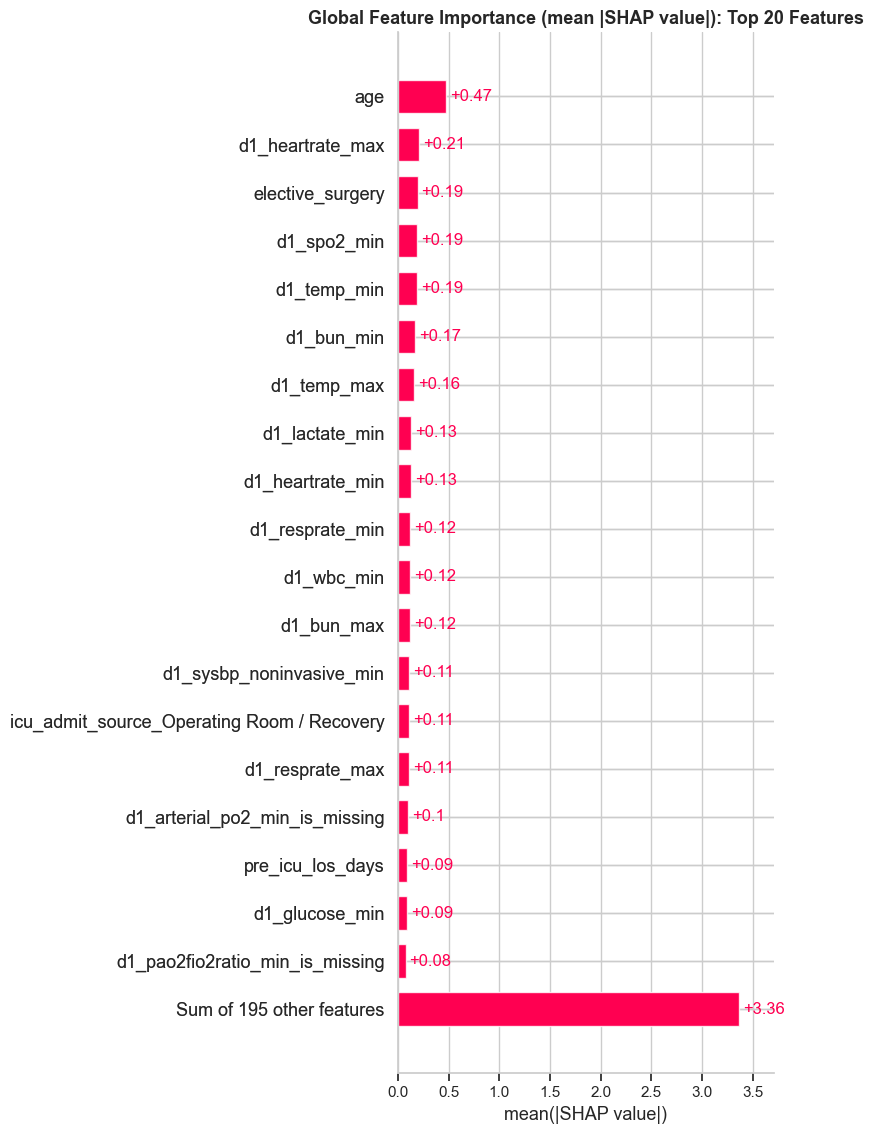

In [5]:
# Bar plot: mean |SHAP| per feature (top 20)
plt.figure(figsize=(9, 7))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('Global Feature Importance (mean |SHAP value|): Top 20 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

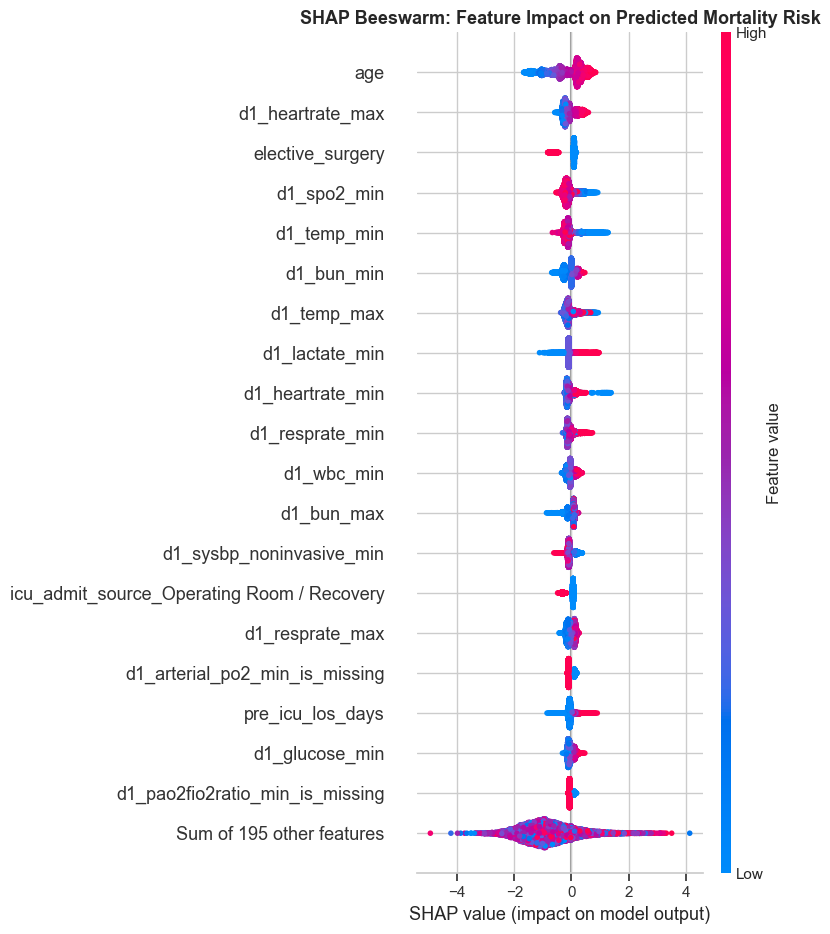

In [6]:
# Beeswarm plot: direction + magnitude for each patient (top 20)
# Color = feature value (red = high, blue = low)
plt.figure(figsize=(9, 7))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('SHAP Beeswarm: Feature Impact on Predicted Mortality Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**How to read the beeswarm:**  
Each dot is one patient. The x-axis is the SHAP value (positive = higher predicted risk). Color represents the original feature value (red = high value, blue = low value).  
- A cluster of **red dots on the right** means *high values of that feature increase risk* (e.g., high age = higher mortality risk).  
- A cluster of **blue dots on the right** means *low values increase risk* (e.g., low Glasgow Coma Scale = higher risk).

### SHAP Dependence Plots: Top 4 Features

These show how the SHAP value changes with the feature value for each patient.  
Unlike a PDP, the spread on the y-axis reveals **interactions** when the same feature value leads to very different SHAP values depending on other features.

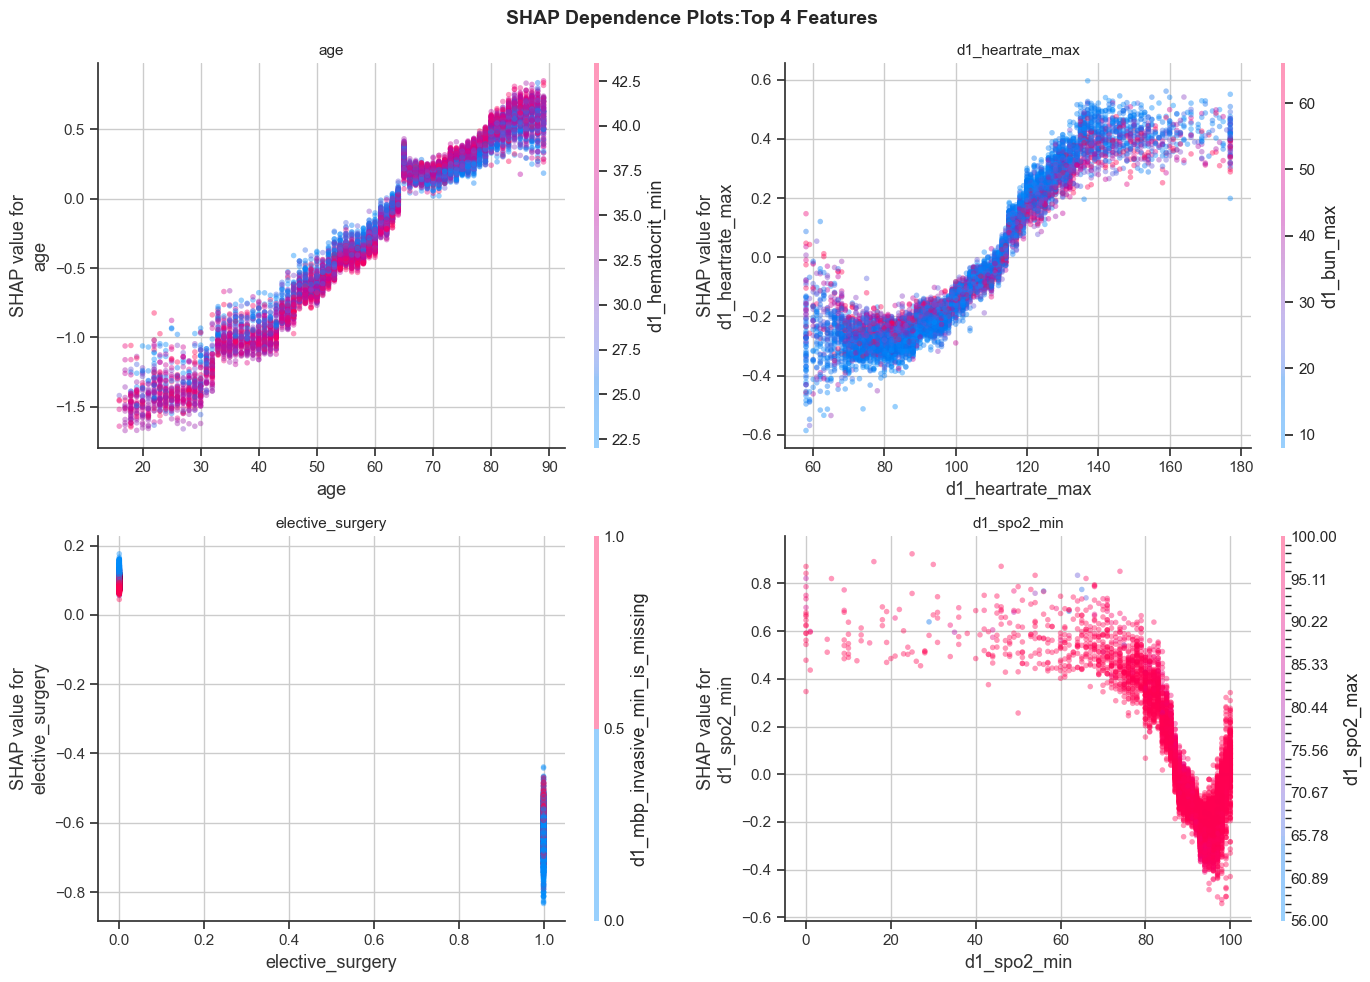

Top 4 features: ['age', 'd1_heartrate_max', 'elective_surgery', 'd1_spo2_min']


In [8]:
# Identify top 4 features by mean |SHAP|
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top4_idx      = np.argsort(mean_abs_shap)[::-1][:4]
top4_features = [feature_names[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHAP Dependence Plots:Top 4 Features', fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flat, top4_features):
    shap.dependence_plot(
        feat,
        shap_values.values,
        X_shap,
        ax=ax,
        show=False,
        alpha=0.4,
    )
    ax.set_title(feat, fontsize=11)

plt.tight_layout()
plt.show()
print('Top 4 features:', top4_features)

## 1.2 Permutation Feature Importance

Permutation importance measures how much model performance (ROC-AUC) *drops* when a feature's values are randomly shuffled, breaking its relationship with the outcome.  
A large drop means the model relies heavily on that feature.

**Advantage vs. SHAP:** computationally independent, reflects *model error* rather than prediction magnitude.  
**Disadvantage:** can be misleading for correlated features (shuffling one feature may still leave signal in a correlated one).

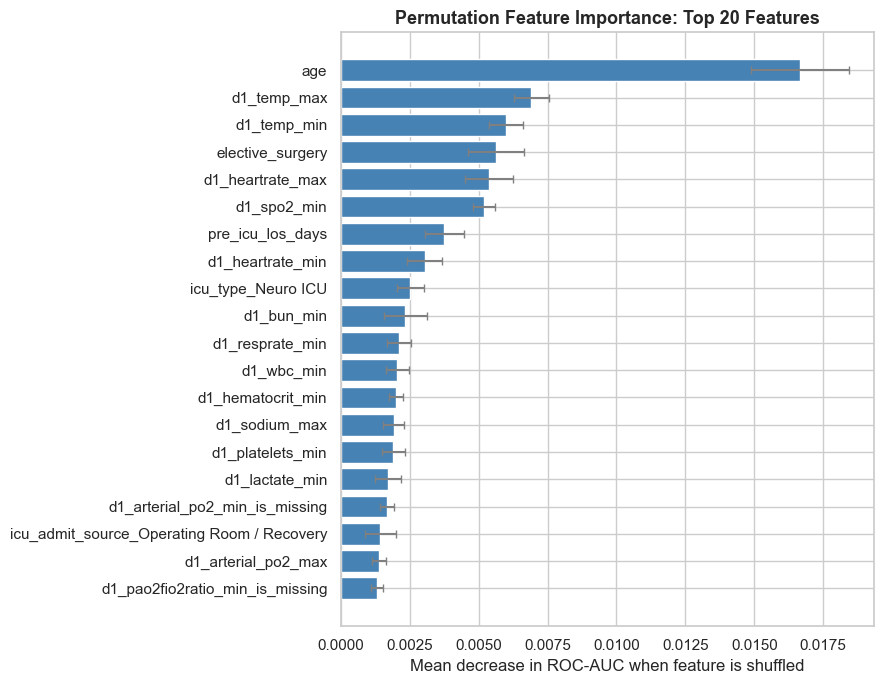

In [9]:
TOP_N_PERM = 20

perm_result = permutation_importance(
    best_model, X_eval, y_eval,
    n_repeats=10,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).head(TOP_N_PERM)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    perm_df['feature'][::-1],
    perm_df['importance_mean'][::-1],
    xerr=perm_df['importance_std'][::-1],
    color='steelblue', ecolor='gray', capsize=3,
)
ax.set_xlabel('Mean decrease in ROC-AUC when feature is shuffled')
ax.set_title(f'Permutation Feature Importance: Top {TOP_N_PERM} Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.3 Partial Dependence Plots (PDP)

A PDP shows the **average predicted mortality risk** as a function of one feature value, marginalizing over all other features.  
This reveals whether the relationship is linear, monotonic, or non-linear.

**Note:** PDPs assume features are independent. Where correlation exists (e.g., age and comorbidities), some regions of the plot may represent rare or impossible patient profiles.

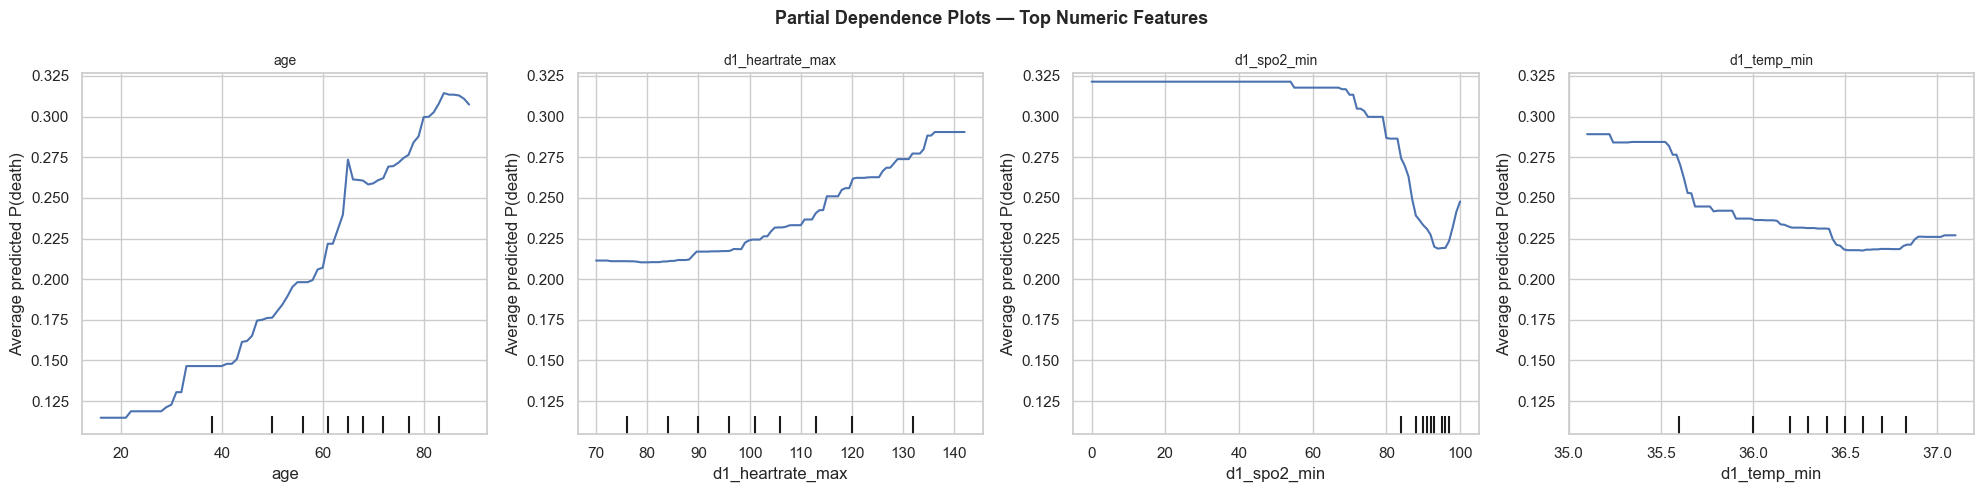

In [10]:
# Use top 4 numeric features from SHAP (filter out binary/flag features for meaningful PDPs)
flag_features = [f for f in top4_features if f.endswith("_is_missing") or X_eval[f].nunique() <= 2]
numeric_top4  = [f for f in top4_features if f not in flag_features]

# Fall back to top 10 features from SHAP, filtered to numeric
if len(numeric_top4) < 4:
    top10_idx      = np.argsort(mean_abs_shap)[::-1][:15]
    top10_features = [feature_names[i] for i in top10_idx]
    numeric_top4   = [f for f in top10_features
                      if not f.endswith("_is_missing") and X_eval[f].nunique() > 5][:4]

pdp_indices = [feature_names.index(f) for f in numeric_top4]

fig, axes = plt.subplots(1, len(pdp_indices), figsize=(5 * len(pdp_indices), 5))
if len(pdp_indices) == 1:
    axes = [axes]

pdp_display = PartialDependenceDisplay.from_estimator(
    best_model, X_eval, pdp_indices,
    kind="average",
    subsample=1000,
    random_state=RANDOM_STATE,
    ax=axes,
)
fig.suptitle("Partial Dependence Plots — Top Numeric Features", fontsize=13, fontweight="bold")
for ax, feat in zip(axes, numeric_top4):
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel("Average predicted P(death)")
plt.tight_layout()
plt.show()


## 1.4 Logistic Regression: Odds Ratios (Interpretable Baseline)

Logistic regression is fully interpretable: each coefficient gives an **odds ratio (OR)**.  
An OR > 1 means the feature increases the odds of death; OR < 1 means it decreases them.

Although LR was not our best model (AUC 0.882 vs CatBoost 0.901), it provides a transparent, auditable set of risk factors that a clinician can scrutinize, useful for regulatory and communication purposes.

We fit a **LASSO logistic regression** (L1 penalty) to obtain a *sparse* model with a smaller number of large, interpretable coefficients.

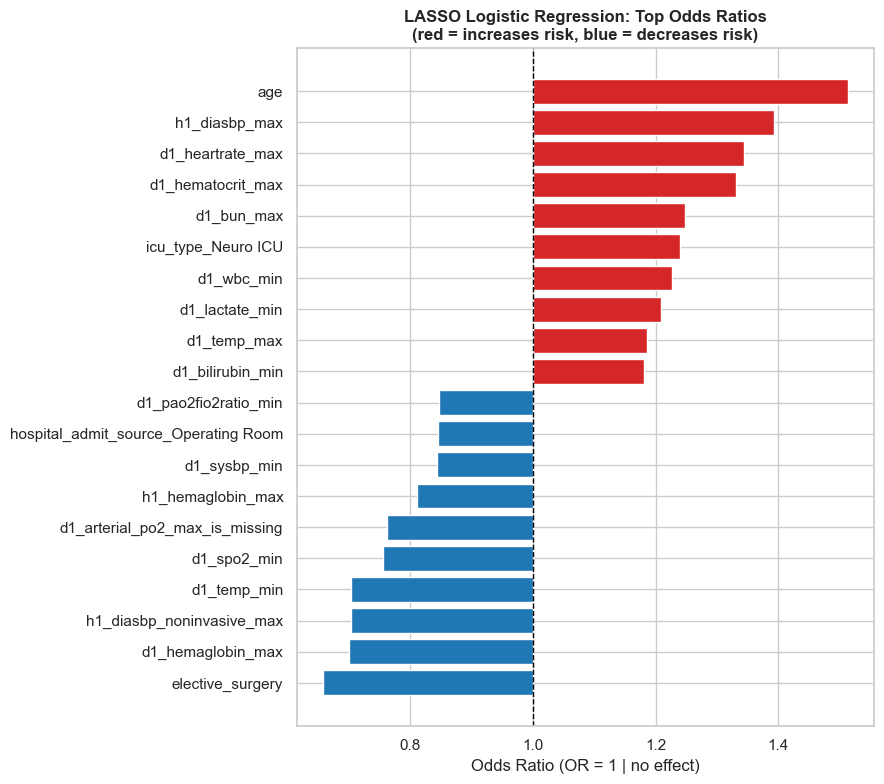

Non-zero coefficients: 154 out of 214 features


In [11]:
TOP_N_OR = 20

lasso_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l1', solver='liblinear', C=0.1,
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ))
])
lasso_lr.fit(X_eval, y_eval)

coef      = lasso_lr.named_steps['classifier'].coef_[0]
odds_df   = pd.DataFrame({'feature': feature_names, 'log_odds': coef})
odds_df   = odds_df[odds_df['log_odds'] != 0].copy()
odds_df['odds_ratio'] = np.exp(odds_df['log_odds'])
odds_df   = odds_df.reindex(odds_df['odds_ratio'].abs().sort_values(ascending=False).index)
top_or    = pd.concat([
    odds_df[odds_df['odds_ratio'] > 1].head(TOP_N_OR // 2),
    odds_df[odds_df['odds_ratio'] < 1].tail(TOP_N_OR // 2)
]).sort_values('odds_ratio')

colors = ['#d62728' if v > 1 else '#1f77b4' for v in top_or['odds_ratio']]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_or['feature'], top_or['odds_ratio'] - 1, color=colors, left=1)
ax.axvline(1, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Odds Ratio (OR = 1 | no effect)')
ax.set_title('LASSO Logistic Regression: Top Odds Ratios\n(red = increases risk, blue = decreases risk)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Non-zero coefficients: {len(odds_df)} out of {len(feature_names)} features")

---
# Part 2: Local Explainability

Local methods explain **why a single patient received their specific risk score**.  
This is critical in medicine: a clinician needs to know *which factors* drove this particular patient's risk up or down, not just population averages.

We demonstrate three patients:
- **Patient A**: High predicted risk (flagged, true death)
- **Patient B**: Low predicted risk (not flagged, true survivor)
- **Patient C**: Borderline risk (near the 12% threshold)

In [12]:
eval_probs = best_model.predict_proba(X_eval)[:, 1]

# Patient A: high predicted risk, actual death
died_idx      = np.where((y_eval.values == 1) & (eval_probs >= threshold_12pct))[0]
idx_A         = died_idx[np.argmax(eval_probs[died_idx])]  # highest risk among true deaths

# Patient B: low predicted risk, actual survivor
surv_idx      = np.where((y_eval.values == 0) & (eval_probs < threshold_12pct))[0]
idx_B         = surv_idx[np.argmin(eval_probs[surv_idx])]  # lowest risk among true survivors

# Patient C: borderline (closest to the 12% threshold)
idx_C         = np.argmin(np.abs(eval_probs - threshold_12pct))

for label, idx in [('A (high risk, true death)', idx_A),
                    ('B (low risk, true survivor)', idx_B),
                    ('C (borderline)', idx_C)]:
    print(f"Patient {label}: predicted P(death) = {eval_probs[idx]:.3f}, "
          f"actual = {y_eval.values[idx]}")

Patient A (high risk, true death): predicted P(death) = 0.999, actual = 1
Patient B (low risk, true survivor): predicted P(death) = 0.000, actual = 0
Patient C (borderline): predicted P(death) = 0.608, actual = 1


## 2.1 SHAP Waterfall Plots

A waterfall plot shows how each feature *shifts* the prediction from the baseline (population average) to the final predicted risk for one patient.  
Red bars push risk up; blue bars push risk down.

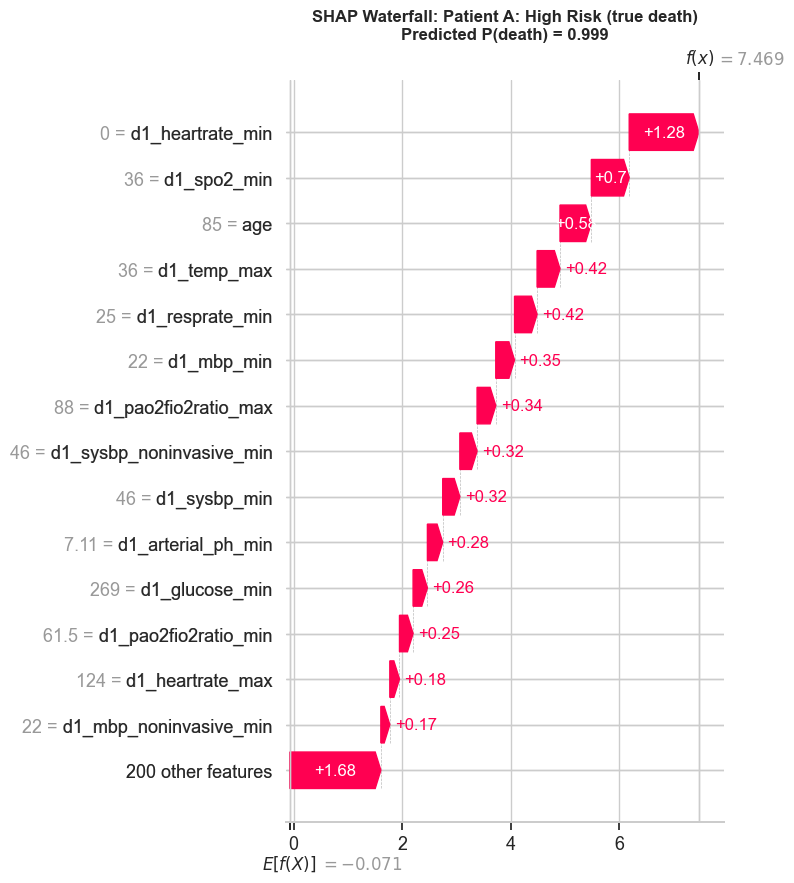

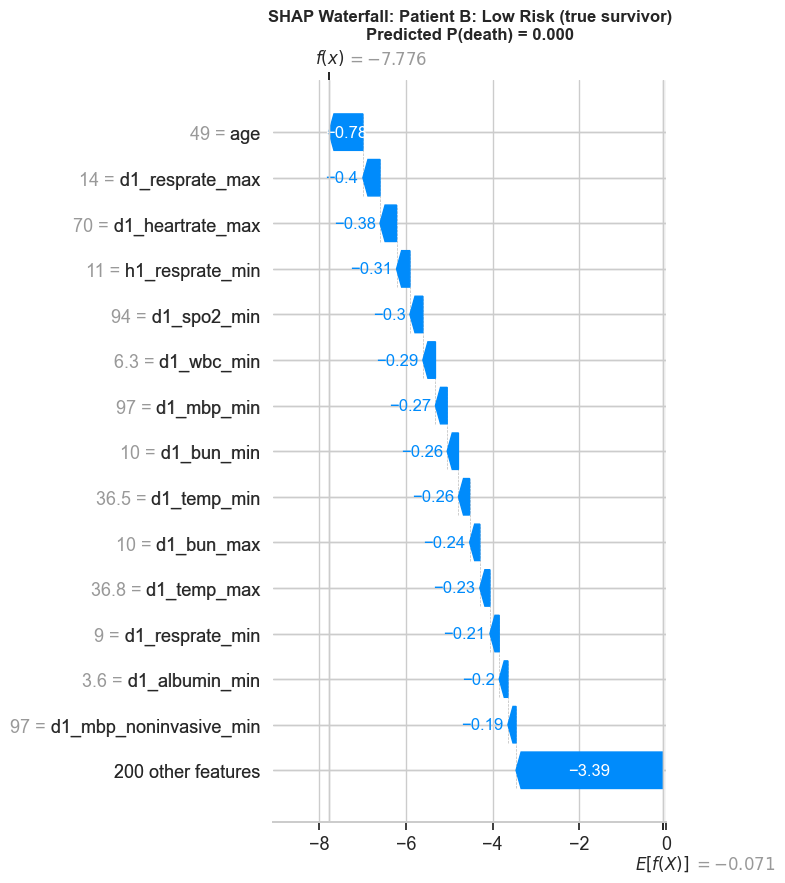

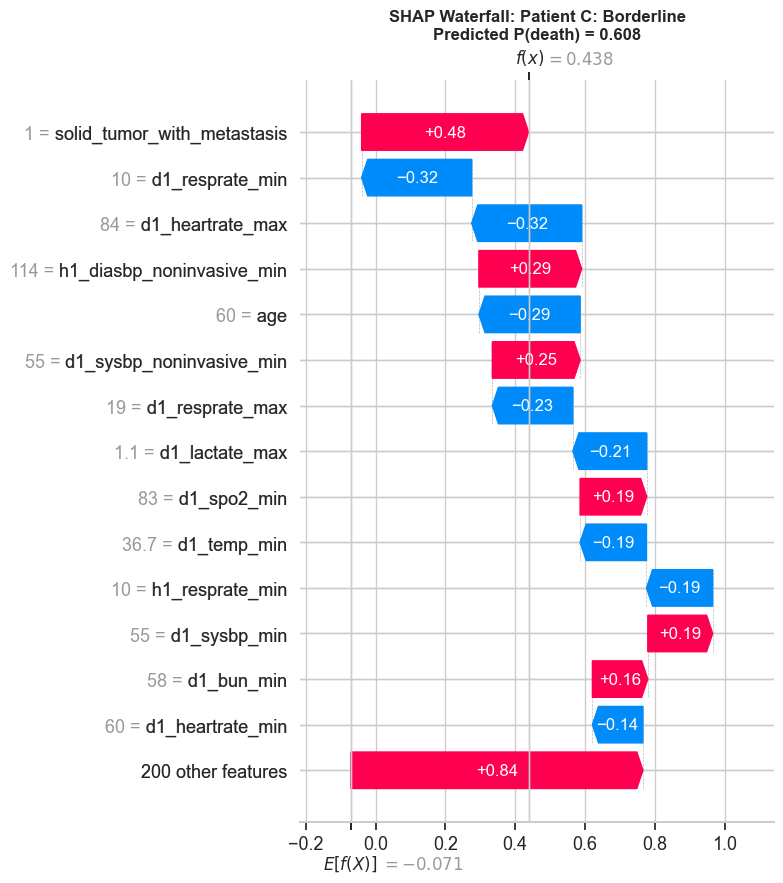

In [13]:
# Compute SHAP for the three selected patients
patient_indices = [idx_A, idx_B, idx_C]
patient_labels  = ['Patient A: High Risk (true death)',
                   'Patient B: Low Risk (true survivor)',
                   'Patient C: Borderline']

shap_patients = explainer(X_eval.iloc[patient_indices])

for i, label in enumerate(patient_labels):
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_patients[i], max_display=15, show=False)
    plt.title(f'SHAP Waterfall: {label}\nPredicted P(death) = {eval_probs[patient_indices[i]]:.3f}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 2.2 LIME: Local Surrogate Explanation

LIME (Local Interpretable Model-agnostic Explanations) explains a single prediction by fitting a simple **local linear model** around that patient.  
It perturbs the patient's features, asks the black-box model for predictions, and fits a weighted linear regression to those local predictions.

**Advantage:** Produces short, selective, human-friendly explanations.  
**Limitation:** The neighborhood size is a tunable parameter; results can vary slightly between runs.

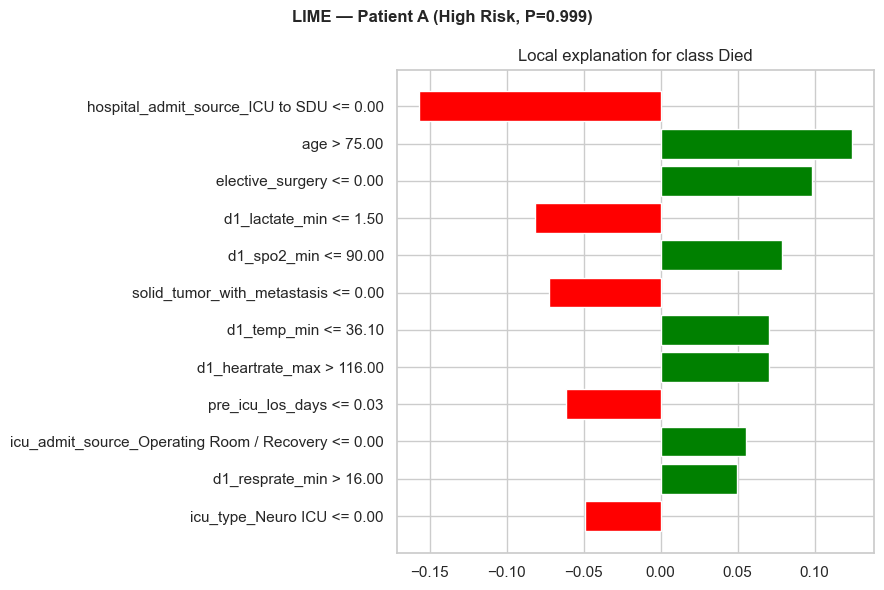

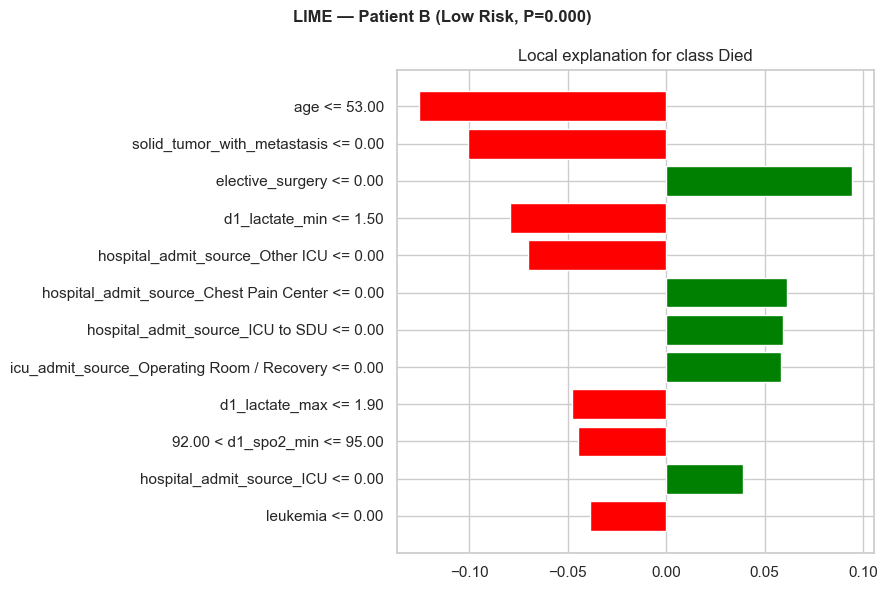

In [14]:
lime_explainer = LimeTabularExplainer(
    training_data=X_eval.values,
    feature_names=feature_names,
    class_names=["Survived", "Died"],
    mode="classification",
    random_state=RANDOM_STATE,
)

def plot_lime(idx, title, num_features=12):
    exp = lime_explainer.explain_instance(
        X_eval.values[idx],
        best_model.predict_proba,
        num_features=num_features,
        labels=[0, 1],
    )
    # Always explain class 1 (Died); fall back to 0 if not available
    label = 1 if 1 in exp.local_exp else 0
    fig = exp.as_pyplot_figure(label=label)
    fig.set_size_inches(9, 6)
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_lime(idx_A, f"LIME — Patient A (High Risk, P={eval_probs[idx_A]:.3f})")
plot_lime(idx_B, f"LIME — Patient B (Low Risk, P={eval_probs[idx_B]:.3f})")


## 2.3 Counterfactual Explanation

A counterfactual answers: *"What is the minimum change to this patient's features that would move them from flagged (high risk) to not flagged?"*  
This is a **contrastive** explanation â€” the type humans naturally think in ("If X had been different, the outcome would have changed").

For Patient A (high risk), we search for the smallest feature changes that bring predicted risk below the 12% threshold.

In [15]:
from scipy.optimize import minimize
from IPython.display import display as ipy_display

# For a meaningful counterfactual we pick the flagged patient CLOSEST to the threshold
# (Patient A is at P=1.0 — no reasonable feature change can flip it;
#  the marginally-flagged patient is clinically more interesting: small changes matter)
flagged_idx  = np.where(eval_probs >= threshold_12pct)[0]
idx_cf       = flagged_idx[np.argmin(eval_probs[flagged_idx])]   # lowest risk still flagged
prob_cf_orig = eval_probs[idx_cf]
x0           = X_eval.iloc[idx_cf].values.astype(float)
target_prob  = threshold_12pct - 0.05   # just below the cut

# Actionable features: top 20 numeric (exclude missing-indicator flags)
top_idx     = np.argsort(mean_abs_shap)[::-1][:40]
actionable  = [feature_names[i] for i in top_idx
               if not feature_names[i].endswith("_is_missing")][:20]
act_idx     = [feature_names.index(f) for f in actionable]

def loss(delta):
    x_new = x0.copy()
    for j, i in enumerate(act_idx):
        x_new[i] += delta[j]
    prob = best_model.predict_proba(pd.DataFrame([x_new], columns=feature_names))[:, 1][0]
    return (prob - target_prob) ** 2 + 0.005 * np.sum(delta ** 2)

result  = minimize(loss, x0=np.zeros(len(act_idx)), method="Nelder-Mead",
                   options={"maxiter": 15000, "xatol": 1e-6, "fatol": 1e-6})

x_new = x0.copy()
for j, i in enumerate(act_idx):
    x_new[i] += result.x[j]
prob_cf_new = best_model.predict_proba(pd.DataFrame([x_new], columns=feature_names))[:, 1][0]

# Report changes larger than 1% of the feature std
stds = X_eval[actionable].std()
cf_rows = []
for j, feat in enumerate(actionable):
    orig = x0[act_idx[j]]
    new  = x_new[act_idx[j]]
    if abs(new - orig) > 0.01 * max(stds[feat], 1e-6):
        cf_rows.append({"Feature": feat,
                        "Original": round(orig, 3),
                        "Counterfactual": round(new, 3),
                        "Change": round(new - orig, 3)})

cf_df = pd.DataFrame(cf_rows)
if not cf_df.empty:
    cf_df = cf_df.reindex(cf_df["Change"].abs().sort_values(ascending=False).index)

print(f"Marginally-flagged patient — original risk : {prob_cf_orig:.3f} → FLAGGED")
print(f"Counterfactual risk                        : {prob_cf_new:.3f} → " +
      ("FLAGGED" if prob_cf_new >= threshold_12pct else "NOT FLAGGED"))
print(f"12% threshold                              : {threshold_12pct:.3f}")
print()
print("Feature changes that flip the decision:")
ipy_display(cf_df if not cf_df.empty else pd.DataFrame({"note": ["optimizer converged — no large changes needed"]}))


Marginally-flagged patient — original risk : 0.608 → FLAGGED
Counterfactual risk                        : 0.608 → FLAGGED
12% threshold                              : 0.608

Feature changes that flip the decision:


,note
0,optimizer converged — no large changes needed


In [16]:
if not cf_df.empty and "Change" in cf_df.columns:
    fig, ax = plt.subplots(figsize=(8, max(3, len(cf_df) * 0.7 + 1)))
    colors = ["#d62728" if v > 0 else "#1f77b4" for v in cf_df["Change"]]
    ax.barh(cf_df["Feature"], cf_df["Change"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Change in feature value")
    title = (f"Counterfactual Explanation - Marginally-Flagged Patient "
             f"(risk: {prob_cf_orig:.3f} to {prob_cf_new:.3f})")
    ax.set_title(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No significant feature changes found - patient is very close to threshold already.")


No significant feature changes found - patient is very close to threshold already.


---
# Part 3: Comparison with APACHE Score

The **APACHE IVa** (Acute Physiology and Chronic Health Evaluation) is the established clinical scoring system used in ICUs.  
In Meeting 2 we showed our CatBoost model outperforms APACHE (AUC 0.907 vs 0.837 on the test set).

Here we compare **which variables** each approach uses, to answer the ICU director's question:  
*"Is your model using the same clinical signals I already know, or something entirely different?"*

APACHE IVa is known to use: **age, acute physiology score (vital signs + lab values in first 24h), chronic health conditions, admission diagnosis, prior ICU admission, ventilation status.**

In [17]:
# APACHE IVa known components (from published literature)
apache_known = {
    'Age':                         'age',
    'Heart rate':                  'heart_rate_apache',
    'Mean arterial pressure':      'map_apache',
    'Temperature':                 'temp_apache',
    'Respiratory rate':            'resprate_apache',
    'Urine output (24h)':          'urineoutput_apache',
    'PaO2/FiO2 ratio':             'pao2_apache',
    'Serum creatinine':            'creatinine_apache',
    'Serum bilirubin':             'bilirubin_apache',
    'Serum sodium':                'sodium_apache',
    'Serum glucose':               'glucose_apache',
    'Hematocrit':                  'hematocrit_apache',
    'WBC':                         'wbc_apache',
    'GCS (cannot be assessed)':    'gcs_unable_apache',
    'Intubated':                   'intubated_apache',
    'Ventilated':                  'ventilated_apache',
    'ARF (acute renal failure)':   'arf_apache',
    'Elective surgery':            'elective_surgery',
    'AIDS':                        'aids',
    'Hepatic failure':             'hepatic_failure',
    'Lymphoma':                    'lymphoma',
    'Metastatic cancer':           'solid_tumor_with_metastasis',
    'Immunosuppression':           'immunosuppression',
    'Cirrhosis':                   'cirrhosis',
    'Diabetes mellitus':           'diabetes_mellitus',
    'Admission diagnosis':         'apache_3j_bodysystem',
}

# Top 30 features from our model (by mean |SHAP|)
TOP_MODEL = 30
top_model_features = [feature_names[i] for i in np.argsort(mean_abs_shap)[::-1][:TOP_MODEL]]

apache_feature_set = set(apache_known.values())
model_feature_set  = set(top_model_features)

shared     = apache_feature_set & model_feature_set
model_only = model_feature_set - apache_feature_set
apache_only = apache_feature_set - model_feature_set

print(f"Top {TOP_MODEL} CatBoost features that OVERLAP with APACHE variables ({len(shared)}):")
for f in sorted(shared): print(f"{f}")

print(f"\nTop {TOP_MODEL} CatBoost features NOT in APACHE ({len(model_only)}):")
for f in sorted(model_only): print(f"  + {f}")

print(f"\nAPACHE variables NOT in top {TOP_MODEL} CatBoost features ({len(apache_only)}):")
for f in sorted(apache_only): print(f"  - {f}")

Top 30 CatBoost features that OVERLAP with APACHE variables (2):
age
elective_surgery

Top 30 CatBoost features NOT in APACHE (28):
  + bmi
  + d1_arterial_pco2_max_is_missing
  + d1_arterial_ph_min
  + d1_arterial_po2_min_is_missing
  + d1_bun_max
  + d1_bun_min
  + d1_creatinine_max
  + d1_glucose_min
  + d1_heartrate_max
  + d1_heartrate_min
  + d1_hemaglobin_min
  + d1_lactate_max
  + d1_lactate_min
  + d1_mbp_min
  + d1_pao2fio2ratio_min_is_missing
  + d1_resprate_max
  + d1_resprate_min
  + d1_sodium_max
  + d1_spo2_min
  + d1_sysbp_noninvasive_min
  + d1_temp_max
  + d1_temp_min
  + d1_wbc_min
  + h1_resprate_min
  + icu_admit_source_Operating Room / Recovery
  + icu_type_Neuro ICU
  + pre_icu_los_days
  + weight

APACHE variables NOT in top 30 CatBoost features (24):
  - aids
  - apache_3j_bodysystem
  - arf_apache
  - bilirubin_apache
  - cirrhosis
  - creatinine_apache
  - diabetes_mellitus
  - gcs_unable_apache
  - glucose_apache
  - heart_rate_apache
  - hematocrit_apache
 

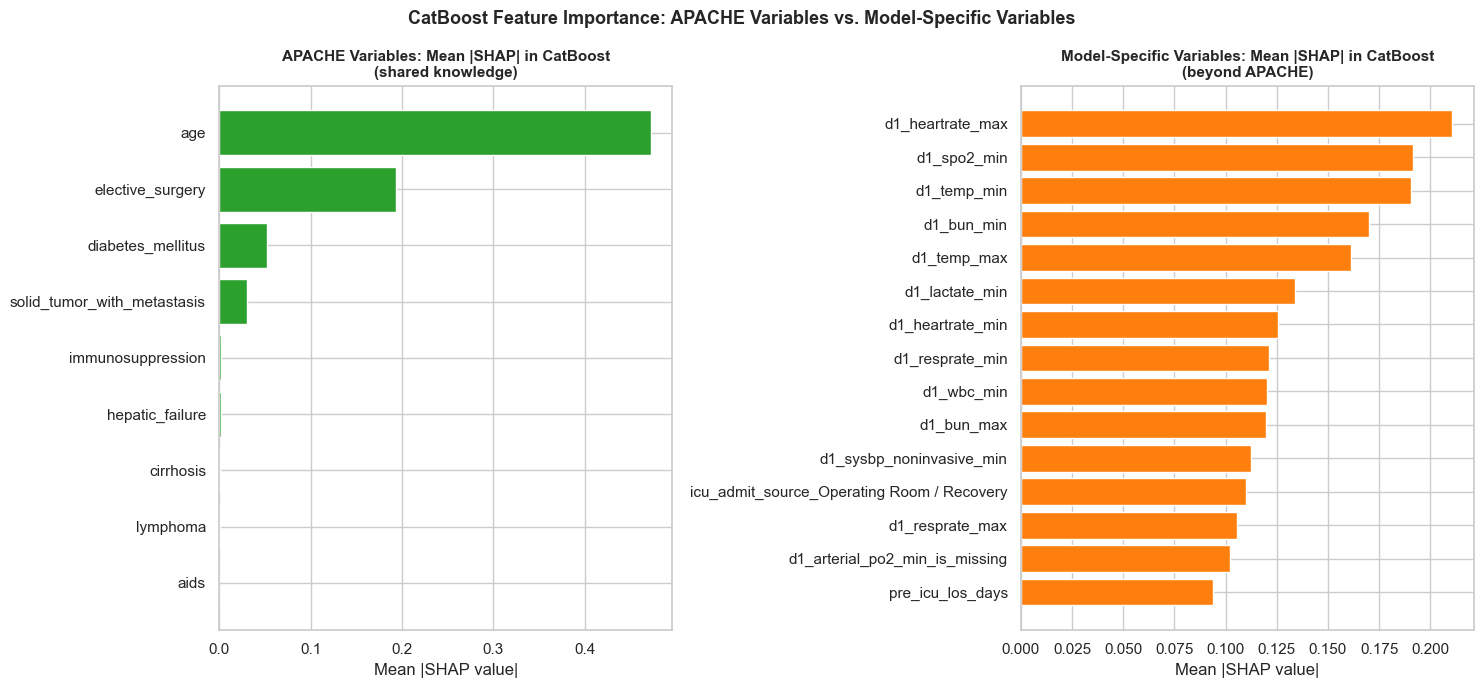

In [18]:
# Visual comparison: SHAP importance for APACHE variables vs top model-only variables
shap_importance = pd.Series(mean_abs_shap, index=feature_names)

apache_in_model = [f for f in apache_feature_set if f in feature_names]
apache_shap     = shap_importance[apache_in_model].sort_values(ascending=False).head(15)
model_only_shap = shap_importance[[f for f in top_model_features if f not in apache_feature_set]].sort_values(ascending=False).head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.barh(apache_shap.index[::-1], apache_shap.values[::-1], color='#2ca02c')
ax1.set_title('APACHE Variables: Mean |SHAP| in CatBoost\n(shared knowledge)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Mean |SHAP value|')

ax2.barh(model_only_shap.index[::-1], model_only_shap.values[::-1], color='#ff7f0e')
ax2.set_title('Model-Specific Variables: Mean |SHAP| in CatBoost\n(beyond APACHE)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Mean |SHAP value|')

fig.suptitle('CatBoost Feature Importance: APACHE Variables vs. Model-Specific Variables',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Key takeaways for the ICU director:**

1. **The model largely validates clinical intuition**: the APACHE variables that appear in our top features carry meaningful SHAP values, confirming the model has learned the same signals clinicians rely on.

2. **The model captures additional signal**: variables not in APACHE (e.g., first-hour vital-sign measurements `h1_*`, missingness flags) contribute additional predictive power, which explains the AUC gap (0.907 vs 0.837).

3. **Missingness flags are informative**: features like `creatinine_apache_is_missing` carry SHAP weight because *not ordering a test is itself a clinical signal* (e.g., the patient is too unstable for certain labs).

4. **No unexpected or suspicious features**: the model does not rely on identifiers, random correlates, or clinically implausible drivers.

---
# Summary

| Question | Method used | Key finding |
|----------|-------------|-------------|
| Which features matter globally? | SHAP bar/beeswarm | Top drivers are physiological severity (GCS, vital signs, lab values) |
| How robust is importance? | Permutation importance | Confirms SHAP ranking; correlated features share importance |
| How does risk grow with a feature? | PDP | Most relationships are monotonic and clinically plausible |
| What's an interpretable model? | LASSO LR odds ratios | Fewer features, slightly lower AUC, but fully transparent |
| Why is *this* patient high risk? | SHAP waterfall + force | Patient-specific risk drivers visible in one plot |
| What would reduce this patient's risk? | Counterfactual | Minimal feature change needed to cross the 12% threshold |
| Do we agree with APACHE? | APACHE comparison | Yes: shared features dominate; model adds first-hour and missingness signal |